# **Social Media Impact on Teen Mental Health**

In [250]:
import pandas as pd

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report , accuracy_score
from sklearn.preprocessing import  StandardScaler

from imblearn.over_sampling import SMOTE 

import matplotlib.pyplot as plt


In [251]:
df = pd.read_csv('https://raw.githubusercontent.com/ChickenMan-1080/ML-Practice/refs/heads/main/ML-Social_Media_Teen_MentalHealth/assets/Teen_Mental_Health_Dataset.csv')
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [252]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [253]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [254]:
df_y = df['depression_label']
df_y = pd.DataFrame(df_y)
df_y

,depression_label
0,0
1,0
2,0
3,0
4,0
...,...
1195,0
1196,0
1197,0
1198,0


In [255]:
df_X = df.drop(df_y,axis=1)
df_X

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9


,count
depression_label,
0,1169
1,31


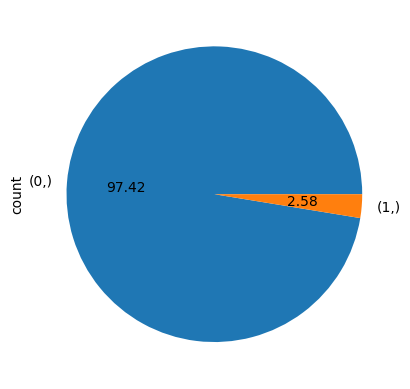

In [256]:
df_y.value_counts().plot.pie(autopct='%.2f')
df_y.value_counts()

ตรงจะติดสินใจทำ Over sampling SMOTE เนื่องจากข้อมูลไม่สมดุลอย่างรุนแรง

<Axes: xlabel='age', ylabel='academic_performance'>

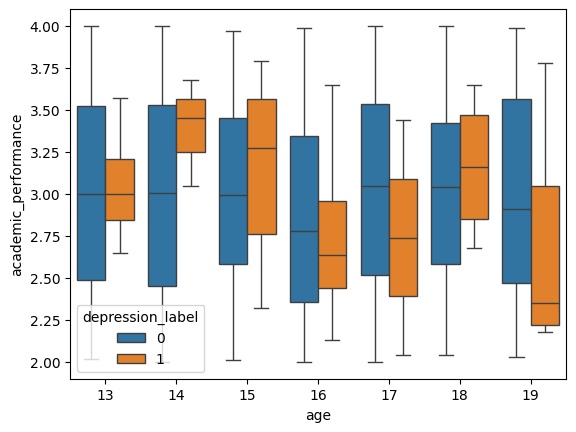

In [257]:
sns.boxplot(data=df,x='age',y='academic_performance',hue='depression_label')

<Axes: xlabel='social_interaction_level', ylabel='academic_performance'>

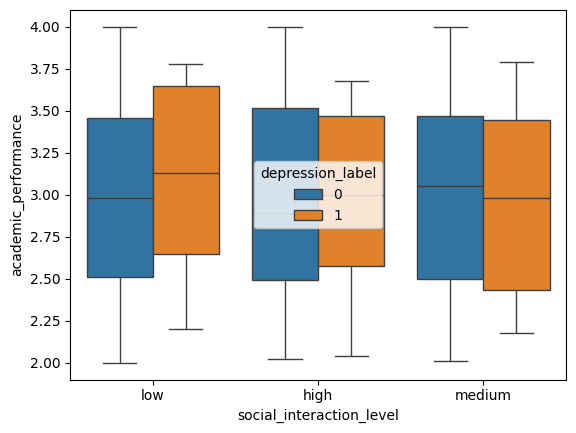

In [258]:
sns.boxplot(df,x='social_interaction_level',y='academic_performance',hue='depression_label')

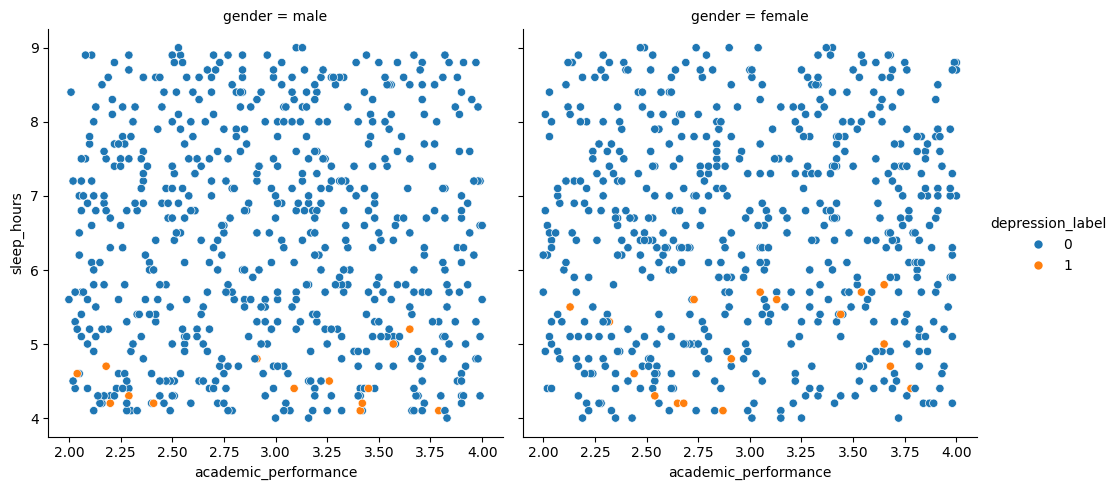

In [259]:
sns.relplot(df,x='academic_performance',y='sleep_hours',hue='depression_label',col='gender')

Sleep_hour เป็น feature ที่แข็งแรงมากบน dataset นี้

# Encode Data

In [260]:
df_encoded = pd.get_dummies(df,columns=['gender','platform_usage','social_interaction_level'],dtype=int)
df_encoded

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,gender_female,gender_male,platform_usage_Both,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_high,social_interaction_level_low,social_interaction_level_medium
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,0,0,1,0,1,0,0,1,0
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,0,1,0,0,0,1,1,0,0
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,0,1,0,0,1,0,1,0,0
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,0,0,1,0,0,1,0,0,1
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,0,1,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,6.8,6.6,2.0,2.76,1.0,3,4,4,0,1,0,0,1,0,0,1,0
1196,16,2.3,8.0,1.9,2.12,0.4,7,4,4,0,0,1,1,0,0,1,0,0
1197,14,1.7,8.7,0.7,3.98,0.8,1,1,1,0,1,0,1,0,0,1,0,0
1198,15,3.9,8.5,2.1,3.19,0.6,7,9,9,0,0,1,1,0,0,1,0,0


# Split Data

In [261]:
df_encoded_X = df_encoded.drop(['depression_label','age','academic_performance'],axis=1)
df_encoded_y = df_encoded['depression_label']

df_encoded_y


,depression_label
0,0
1,0
2,0
3,0
4,0
...,...
1195,0
1196,0
1197,0
1198,0


In [262]:
X_train,X_test,y_train,y_test = train_test_split(df_encoded_X,df_encoded_y,test_size=0.2,random_state=42)

# SMOTE

In [263]:
smote = SMOTE(random_state=42)

In [264]:
X_resampled, y_resampled = smote.fit_resample(X_train,y_train)
X_resampled

,daily_social_media_hours,sleep_hours,screen_time_before_sleep,physical_activity,stress_level,anxiety_level,addiction_level,gender_female,gender_male,platform_usage_Both,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_high,social_interaction_level_low,social_interaction_level_medium
0,6.100000,8.100000,1.400000,1.600000,10,1,4,1,0,0,1,0,0,1,0
1,5.700000,7.500000,2.400000,1.300000,10,10,2,1,0,0,1,0,0,0,1
2,1.100000,7.100000,1.800000,0.800000,5,5,10,0,1,0,0,1,1,0,0
3,5.300000,4.300000,1.500000,0.300000,7,7,10,1,0,0,0,1,1,0,0
4,6.400000,6.000000,1.100000,0.900000,8,2,3,1,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1865,5.255469,5.600000,2.054695,0.765634,7,9,4,1,0,0,0,0,0,0,0
1866,7.248518,4.151482,2.305927,1.017781,10,9,2,1,0,0,0,0,0,1,0
1867,6.865993,4.235923,1.812613,0.467003,10,7,9,0,1,0,0,0,0,0,0
1868,7.196475,5.622115,1.311541,0.381410,8,8,9,1,0,0,0,0,1,0,0


In [265]:
classX_count = pd.DataFrame(y_resampled)
classX_count

,depression_label
0,0
1,0
2,0
3,1
4,0
...,...
1865,1
1866,1
1867,1
1868,1


In [266]:
model = LogisticRegression(max_iter=3000,random_state = 42)
model.fit(X_resampled,y_resampled)
y_pred_smote = model.predict(X_test)

# Evaluation Mericx

In [267]:
print(f'Accuracy : {accuracy_score(y_test,y_pred_smote)}')

Accuracy : 0.9583333333333334


In [268]:
print(classification_report(y_test,y_pred_smote))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       234
           1       0.36      0.83      0.50         6

    accuracy                           0.96       240
   macro avg       0.68      0.90      0.74       240
weighted avg       0.98      0.96      0.97       240



<Axes: >

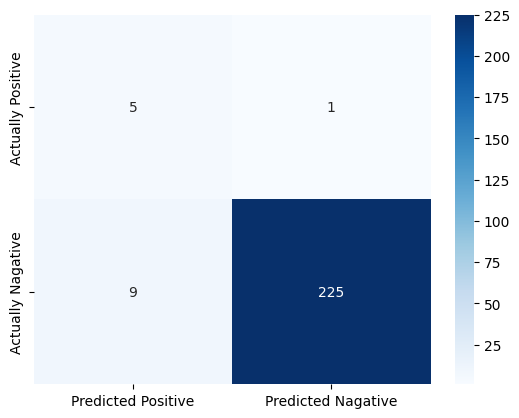

In [269]:
cm = confusion_matrix(y_test,y_pred_smote,labels=[1,0])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',yticklabels=['Actually Positive','Actually Nagative'],xticklabels=['Predicted Positive','Predicted Nagative'])

In [270]:
print("Classes order:", model.classes_)
print("Confusion Matrix:\n", cm)
print("y_test unique values:", y_test.unique())

Classes order: [0 1]
Confusion Matrix:
 [[  5   1]
 [  9 225]]
y_test unique values: [0 1]


In [271]:
import numpy as np

importance = model.coef_[0]
feature_names = X_resampled.columns

# 2. สร้าง DataFrame เพื่อให้ดูง่ายและเรียงลำดับ
feat_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# เรียงลำดับตามขนาด (Absolute Value) เพื่อดูว่าตัวไหนมีผลมากสุด
feat_importance['Abs_Importance'] = feat_importance['Importance'].abs()
feat_importance = feat_importance.sort_values(by='Abs_Importance', ascending=False)

                            Feature  Importance
13     social_interaction_level_low   -2.543628
12    social_interaction_level_high   -2.489958
8                       gender_male   -2.472818
10         platform_usage_Instagram   -2.450985
1                       sleep_hours   -2.316566
11            platform_usage_TikTok   -1.769672
14  social_interaction_level_medium   -1.570915
9               platform_usage_Both   -1.280426
0          daily_social_media_hours    1.162631
5                     anxiety_level    0.912367
4                      stress_level    0.797601
3                 physical_activity   -0.626417
2          screen_time_before_sleep   -0.235402
7                     gender_female   -0.227962
6                   addiction_level    0.006059


/tmp/ipykernel_745/957262467.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_importance, palette='viridis')


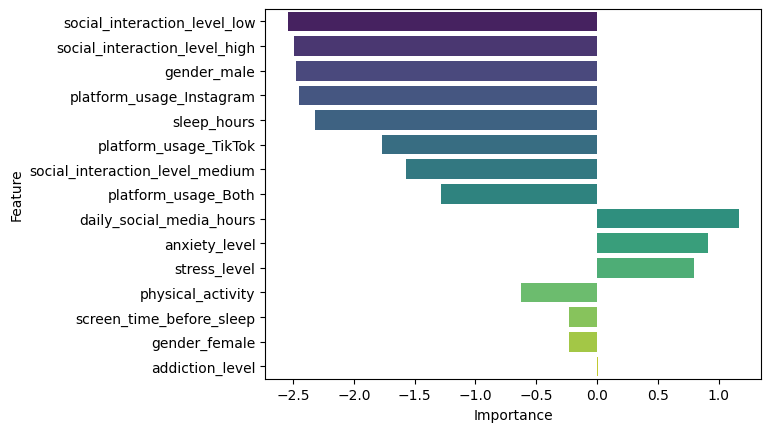

In [272]:
sns.barplot(x='Importance', y='Feature', data=feat_importance, palette='viridis')
print(feat_importance[['Feature', 'Importance']])

In [273]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. เลือกเฉพาะคอลัมน์ที่เป็น Features (X)
# หมายเหตุ: VIF คำนวณจากตัวแปรอิสระเท่านั้น

# 2. คำนวณค่า VIF สำหรับแต่ละ Feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X_resampled.columns
vif_data["VIF"] = [variance_inflation_factor(X_resampled.values, i) for i in range(len(X_resampled.columns))]

# 3. เรียงลำดับจากมากไปน้อย
print(vif_data.sort_values(by="VIF", ascending=False))

                            Feature        VIF
1                       sleep_hours  18.413458
0          daily_social_media_hours  11.069281
5                     anxiety_level   9.378120
4                      stress_level   8.719974
2          screen_time_before_sleep   7.587195
3                 physical_activity   4.622103
6                   addiction_level   4.017573
7                     gender_female   3.829951
8                       gender_male   3.509385
14  social_interaction_level_medium   2.521098
13     social_interaction_level_low   2.395128
12    social_interaction_level_high   2.344710
10         platform_usage_Instagram   2.296237
11            platform_usage_TikTok   2.271591
9               platform_usage_Both   2.269903


AUC Score: 0.9744


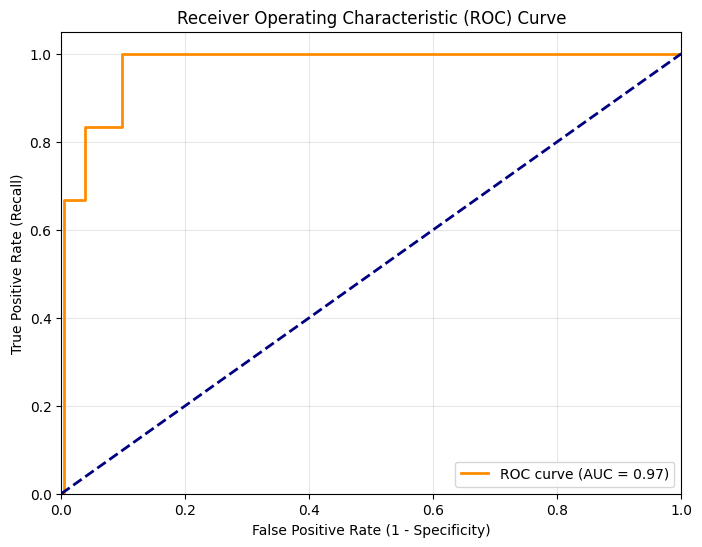

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. ดึงค่าความน่าจะเป็น (Probability) ของคลาส 1
y_probs = model.predict_proba(X_test)[:, 1]

# 2. คำนวณค่า AUC Score
auc_value = roc_auc_score(y_test, y_probs)
print(f"AUC Score: {auc_value:.4f}")

# 3. คำนวณค่าสำหรับพล็อตกราฟ ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# 4. พล็อตกราฟ
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_value:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # เส้นทแยงมุม (Baseline ของการเดาสุ่ม)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()